# Использование LLM через Responses API

В этом ноутбуке мы рассмотрим, как использовать большие языковые модели (LLM) для различных задач, используя OpenAI-совместимый Responses API.

Мы пройдём следующие этапы:
1. Настройка окружения и авторизация
2. Простой запрос к модели
3. Поддержание контекста диалога
4. Извлечение структурированных данных из отзывов с помощью LLM
5. Визуализация и агрегация результатов
6. Использование визуального входа для модели

## 1. Установка библиотек

Для начала, установим необходимые библиотеки:

In [ ]:
%pip install --upgrade openai python-dotenv pandas tqdm shwarsutils

In [ ]:
!pip install "pydantic<2.0"

> **ВНИМАНИЕ**: После установки библиотек рекомендуется перезапустить Kernel ноутбука.

## 2. Авторизация

Для работы с Yandex Cloud нам понадобится `folder_id` (идентификатор каталога) и `api_key` (API-ключ сервисного аккаунта). Мы предполагаем, что эти значения хранятся в файле `.env` в текущей директории.

In [ ]:
!curl -o .env {{url_of_dotenv_file}}

Загружаем значения `folder_id` и `api_key` в одноимённые переменные:

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

print(f"✅ Авторизация настроена (folder_id: {folder_id[:8]}...)")

✅ Авторизация настроена (folder_id: b1gbicod...)


Теперь создадим клиент OpenAI SDK для работы с моделями:

In [ ]:
from openai import OpenAI

model = 'nvidia/nemotron-3-nano-4b'

client = OpenAI(
    base_url="http://localhost:1234/v1",
    api_key='anything',
    #project=folder_id
)

print(f"✅ Клиент создан")

✅ Клиент создан


Обратите внимание, что мы установили свой адрес `base_url` для обращения к модели в облаке Yandex, и использовали специфическое имя модели (содержащее в себе также `folder_id`).

Также добавим вспомогательную функцию для вывода ответа модели в формате Markdown:

In [ ]:
from IPython.display import Markdown, display

def printx(string):
    """Вывод текста в формате Markdown."""
    display(Markdown(string))

## 3. Простой запрос к модели

Responses API — это современный способ взаимодействия с языковой моделью. Он позволяет отправлять запросы и получать ответы, а также поддерживать контекст диалога.

Отправим простой запрос о вокзалах Москвы:

In [ ]:
res = client.responses.create(
    model='nvidia/nemotron-3-nano-4b',
    input="Какой лучший вокзал в Москве?"
)

printx(res.output_text)

При необходимости можно задать системный промпт (инструкцию для модели), который определяет её поведение:

In [ ]:
res = client.responses.create(
    model=model,
    instructions="Ты - эксперт по железнодорожным вокзалам. Отвечай кратко и по делу.",
    input="Какой лучший вокзал в Москве?"
)

printx(res.output_text)

Единого «лучшего» не существует — всё зависит от **куда едете** и **что важнее** (красота, удобство пересадок, близость к центру).

Вот краткий рейтинг по категориям:

### 1. По архитектуре и атмосфере
*   **Казанский** — самый красивый (неорусский стиль, башня Сююмбике, зодиакальный 홀л). Плюс: прямое попадание на метро «Комсомольская» (кольцевая).
*   **Киевский** — сталинскиймпире, фрески, колонны, вид на реку и мост.
*   **Ярославский** — старинный фасад, уютные залы, длинная история (старт Транссиба).

### 2. По удобству пересадок на метро (без выхода на улицу)
*   **Курский / Нижегородский** — общий вестибюль с метро «Курская» (кольцевая и радиальная). Самый быстрый трансфер.
*   **Белорусский** — прямо в зале метро «Белорусская» (кольцевая и зеленая).
*   **Казанский / Ленинградский / Ярославский** — «Комсомольская» (кольцевая) подключена ко всем трём подземными переходами.

### 3. По современному комфорту (после реконструкции)
*   **Внутренний (Круговой / МЦД)** — новые платформы, турникеты, теплые переходы, хорошие инфотабло.
*   **Савеловский (МЦД-1/2)** — полностью обновлен, удобная навигация, современные зоны ожидания.
*   **Рижский** — недавно отремонтирован, чисто, светло, удобные схемы МЦД.

### 4. По लोकации (ближе к центру / отелям)
*   **Ленинградский, Ярославский, Казанский** (площадь Трех Вокзалов) — шаговая доступность до Красной площади (20–30 мин пешком или 2 ст. метро).
*   **Курский / Нижегородский** — очень близко к Центру (Садовое кольцо).
*   **Белорусский** — удобен для прилетающих в Шереметьево (Аэроэкспресс 35 мин).

---

### Итог: какой выбрать?
| Если вам нужно... | Идите на... |
| :--- | :--- |
| **В Петербург (Сапсан/п фирменные)** | **Ленинградский** |
| **На восток, Урал, Сибирь, Китай (Транссиб)** | **Ярославский** |
| **В Казань, Юг Урала, Среднюю Азию** | **Казанский** |
| **На юг (Краснодар, Сочи, Крым, Кавказ)** | **Казанский** (основной) или **Курский** (часть поездов) |
| **В Украину, Молдову, Румынию, Веницию** | **Киевский** |
| **В Белоруссию, Европу (через Минск), в Шереметьево** | **Белорусский** |
| **В Нижний Новгород, Воронеж, Курск, Донбасс** | **Курский / Нижегородский** |
| **По МЦД (пригороды/обменяться на другой радиал)** | **Внутренний, Савеловский, Рижский, Нахабинская** |

**Совет:** Смотрите не на название вокзала, а на **номер поезда и платформу** в билете/приложении РЖД. Один и тот же поезд может менять вокзал отправления из-за ремонтов.

## 4. Поддержание контекста диалога

Responses API позволяет сохранять контекст между запросами. Для этого нужно:
1. Установить `store=True` при первом запросе (хотя это не обязательно, значение `True` используется по умолчанию)
2. Передавать `previous_response_id` в последующих запросах

Попробуем задать уточняющий вопрос:

In [ ]:
# Первый запрос - спрашиваем про лучший вокзал
res = client.responses.create(
    model=model,
    store=False,  # Сохраняем ответ для продолжения диалога
    instructions="Ты - эксперт по железнодорожным вокзалам Москвы. Отвечай кратко.",
    input="Какой лучший вокзал в Москве?"
)

print(f"ID ответа: {res.id}")
printx(res.output_text)

ID ответа: gen-1789422003-IHIQ12PYWGpyrUEMnWfx


Единого «лучшего» нет — зависит от задач. Топ-3 по разным критериям:

1.  **Казанский** — **лучшая архитектура и удобство**. Здание в стиле неорусский модерн, прямая связь с метро «Комсомольская» (Кольцевая/Сокольническая), современные навигация и сервисы. Главные направления: Восток (Казань, Екб, Новосибирск, Владвосток).
2.  **Ярославский** — **лучший для Транссиба и пригорода**. Самый большой по пассажиропотоку, удобный переход на метро «Комсомольская», отличная организация посадки в фирменные поезда (№1/2 «Россия»). Направления: Север, Урал, Сибирь, Дальний Восток, Ярославль, Александров.
3.  **Ленинградский** — **лучший для Петербурга и Северо-Запада**. Историческое здание 1849 г., ближе к центру (метро «Комсомольская» — переход длиннее), запускает «Сапсаны» и «Ласточки». Направления: СПб, Мурманск, Архангельск, Петрозаводск, Тверь.

**Краткий вердикт:**
*   За эстетику и комфорт — **Казанский**.
*   В дальнюю дорогу (Транссиб) — **Ярославский**.
*   В Петербург — **Ленинградский**.

In [ ]:
# Второй запрос - продолжаем диалог
res2 = client.responses.create(
    model=model,
    store=False,
    previous_response_id=res.id,  # Указываем ID предыдущего ответа
    input="А худший?"
)

printx(res2.output_text)

Как видите, модель понимает контекст и отвечает на уточняющий вопрос, зная, что речь идёт о вокзалах Москвы.

Помимо передачи `previous_response_id`, можно также использовать специальный объект **conversation** для хранения контекста диалога, или накапливать весь диалог локально в виде списка отдельных сообщений такого вида:

```
[
  {
    "role": "system",
    "content": "Ты полезный ассистент, который даёт краткие и чёткие ответы."
  },
  {
    "role": "user",
    "content": "Какой лучший вокзал Москвы?"
  },
  {
    "role": "assistant",
    "content": "Киевский."
  },
  {
    "role": "user",
    "content": "А какой худший?"
  }
]
```

## 5. Извлечение структурированных данных из отзывов

Все мнения о вокзалах выше - это мнения языковой модели, почерпнутое из каких-то обучающих данных. Предположим, нам нужно составить мнение о вокзалах на основе каких-то реальных данных, например, отзывах пользователей о железнодорожных вокзалах Москвы с Яндекс.Карт.

### 5.1. Загрузка данных

Мы подготовили небольшую выборку таких данных. Загрузим их:

In [ ]:
from shwars.utils import *
download_file("https://raw.githubusercontent.com/yandex-ai-studio/ai-studio-course/main/data/rail_reviews.zip")
unzip_file("rail_reviews.zip")
print(" ✅ Данные загружены и распакованы.")

 ✅ Данные загружены и распакованы.


Загрузим все отзывы в DataFrame:

In [ ]:
import json
import pandas as pd
from glob import glob

res = []
for fn in glob('*.json'):
    j = json.load(open(fn, encoding='utf-8'))
    for x in j:
        x['station'] = fn.split('_')[1]
    res.extend(j)

df = pd.DataFrame(res)
print(f"Загружено {len(df)} отзывов")
df.head()

Загружено 2269 отзывов


,id,dislike,like,review_text,author,review_rating,datetime,station
0,1511,0,7,"Москва,Рижский вокзал.Только в стихах описыват...",Ольга К.,5,2021-10-03T03:26:45.661Z,Rizhsky
1,1512,0,6,Рядом с вокзалом находится отличный музей желе...,Евгений Патриотов,5,2021-09-01T12:33:14.052Z,Rizhsky
2,1513,1,3,Пару раз в жизни был внутри. Вроде бы лампово....,Василий,3,2022-04-12T19:04:13.666Z,Rizhsky
3,1514,0,3,"Была впервые и хорошо, что приехала заранее. Б...",Раиса Чумичева,3,2022-05-27T18:20:23.944Z,Rizhsky
4,1515,0,6,Мертвый в настоящее время. Само здание красиво...,Алексей А,5,2022-07-09T19:22:57.466Z,Rizhsky


### 5.2. Распределение отзывов по вокзалам

Посмотрим, как отзывы распределены между вокзалами:

<Axes: title={'center': 'Количество отзывов по вокзалам'}, xlabel='station'>

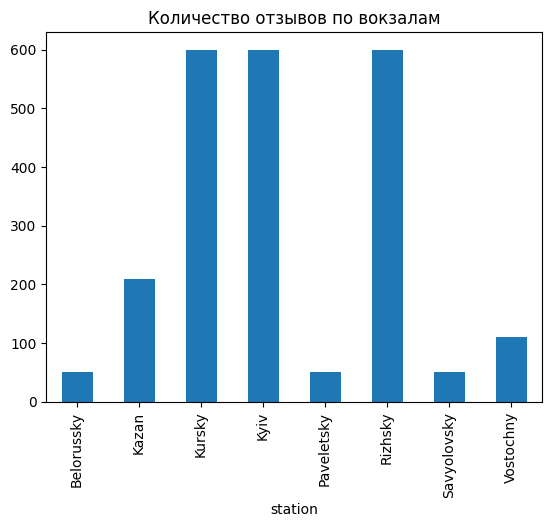

In [ ]:
df.groupby('station')['review_text'].count().plot.bar(title='Количество отзывов по вокзалам')

### 5.3. Извлечение структурированных данных

При наличии отзывов, мы можем извлечь из них какие-то структурированные данные: степень позитивности или негативности отзыва, или даже более подробно плюсы и минусы, упомянутые в тексте.

Для этого мы можем вызвать LLM, и попросить её вернуть нам результат в формате JSON:

In [ ]:
def analyze_review_json(review_text: str) -> dict:
    """
    Анализирует отзыв и возвращает результат в формате JSON.
    """
    prompt = f"""Проанализируй следующий отзыв о железнодорожном вокзале:

```
{review_text}
```

Верни результат в формате JSON:
{{
  "sentiment": "positive/negative/neutral",
  "transport": 0-5,
  "cleanliness": 0-5,
  "schedule": 0-5,
  "positive": ["..."],
  "negative": ["..."],
  "tags": ["..."]
}}

Оценки 1-5, если тема упоминается, или 0, если нет.
"""

    response = client.responses.create(
        model=model,
        instructions="Ты - аналитик отзывов. Отвечай строго в формате JSON.",
        input=prompt
    )

    # Извлекаем JSON из ответа
    text = response.output_text
    # Находим JSON в ответе
    start = text.find('{')
    end = text.rfind('}') + 1
    if start != -1 and end > start:
        return json.loads(text[start:end])
    return None

In [ ]:
sample_review = df['review_text'].iloc[0]
print(f"Отзыв:\n{sample_review}\n")
result_json = analyze_review_json(sample_review)
print("Результат анализа (JSON Mode):")
print(json.dumps(result_json, ensure_ascii=False, indent=2))

Отзыв:
Москва,Рижский вокзал.Только в стихах описывать.Красота.
Цветочный рай.Люблю Москву,любую.

Результат анализа (JSON Mode):
{
  "sentiment": "positive",
  "transport": 0,
  "cleanliness": 0,
  "schedule": 0,
  "positive": [
    "красота вокзала",
    "цветочный рай",
    "любовь к Москве",
    "поэтичное описание"
  ],
  "negative": [],
  "tags": [
    "Рижский вокзал",
    "Москва",
    "эстетика",
    "цветы",
    "позитивные эмоции"
  ]
}


### 5.4. Structured Outputs

Несмотря на то, что мы просили модель вернуть результат в формате JSON, иногда она может ошибаться с форматом или с точным названием полей. Чтобы этого не происходило, Responses API поддерживает так называемый Structured Output — возможность получать ответ модели в строго определённом формате. Для этого проще всего использовать библиотеку `pydantic`, которая позволяет описать точную структуру данных.

Определим модель данных для анализа отзыва:

In [ ]:
from pydantic import BaseModel, Field
from typing import List, Optional
from enum import Enum

class Sentiment(str, Enum):
    positive = "positive"
    negative = "negative"
    neutral = "neutral"

class ReviewAnalysis(BaseModel):
    """Результат анализа отзыва о вокзале."""

    sentiment: Sentiment = Field(description="Тональность отзыва")
    transport: int = Field(description="Оценка транспортной доступности (1-5, или 0 если не упоминается)", ge=0, le=5)
    cleanliness: int = Field(description="Оценка чистоты (1-5, или 0 если не упоминается)", ge=0, le=5)
    schedule: int = Field(description="Оценка точности расписания (1-5, или 0 если не упоминается)", ge=0, le=5)
    positive_points: List[str] = Field(description="Список положительных моментов")
    negative_points: List[str] = Field(description="Список отрицательных моментов")
    tags: List[str] = Field(description="Теги, описывающие основные темы отзыва")

Теперь создадим функцию для анализа отзыва с использованием Structured Outputs:

In [ ]:
def analyze_review_structured(review_text: str) -> ReviewAnalysis:
    """
    Анализирует отзыв и возвращает структурированный результат.
    """
    response = client.responses.parse(
        model=model,
        instructions="""Ты - аналитик отзывов о железнодорожных вокзалах.
Проанализируй отзыв и извлеки структурированную информацию.
Оценки transport, cleanliness, schedule должны быть от 1 до 5, если тема упоминается в отзыве, или 0, если не упоминается.
В positive_points и negative_points включи краткие тезисы из отзыва.
В tags добавь ключевые темы на английском языке.""",
        input=review_text,
        text_format=ReviewAnalysis
    )

    return response.output_parsed

Основные отличия от предыдущего вызова:
* Мы используем `client.responses.parse` вместо `client.responses.create`
* Передаём pydantic-объект в поле `text_format`
* На выходе используем не `response.output_text`, а `response.output_parsed`

Протестируем функцию на одном отзыве:

In [ ]:
print("Отзыв:")
print(sample_review)
print("\nРезультат анализа:")
result = analyze_review_structured(sample_review)
print(result)

Отзыв:
Москва,Рижский вокзал.Только в стихах описывать.Красота.
Цветочный рай.Люблю Москву,любую.

Результат анализа:
sentiment=<Sentiment.positive: 'positive'> transport=0 cleanliness=0 schedule=0 positive_points=['Красота архитектуры и оформления', 'Цветочные композиции («Цветочный рай»)', 'Эстетическое удовольствие от визита'] negative_points=[] tags=['architecture', 'flowers', 'atmosphere', 'aesthetics', 'moscow']


### 5.5. Массовый анализ отзывов

Для ускорения времени демонстрации возьмём выборку — по 5 отзывов с каждого вокзала.

In [ ]:
from tqdm.auto import tqdm

# Выборка по 5 отзывов с каждого вокзала
df_sample = df.groupby('station').apply(lambda x: x.sample(min(1, len(x)), random_state=42)).reset_index(drop=True)
print(f"Выборка: {len(df_sample)} отзывов")

# Анализируем отзывы
results = []
for idx, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Анализ отзывов"):
    analysis = analyze_review_structured(row['review_text']).dict()
    for x in ['review_text']:
        analysis[x] = row[x]
    results.append(analysis)

df_analyzed = pd.DataFrame(results)
print(f"\nУспешно проанализировано: {len(df_analyzed)} отзывов")

На выходе модели для каждого вокзала мы получаем pydantic-объект, превращаем его в словарь с помощью `.dict()`, добавляем название вокзала и исходный текст, и запоминаем все такие словари в списке. Из списка словарей затем легко получить таблицу `df_analyzed:`

In [ ]:
df_analyzed.head(10)

,sentiment,transport,cleanliness,schedule,positive_points,negative_points,tags,station,review_text
0,Sentiment.neutral,4,2,5,"[Красивое здание, Близко к метро Белорусская, ...","[Здание выглядит обветшалым, Неудобно для пасс...","[architecture, proximity to metro, lack of com...",Belorussky,Красивое здание и близкое расположение к станц...
1,Sentiment.positive,5,5,4,"[Удобное расположение в центре города, Легкий ...",[],"[location, public_transport_access, route_vari...",Belorussky,Я хотел бы поделиться своим положительным опыт...
2,Sentiment.positive,0,0,0,"[новое здание с современным залом ожидания, на...",[старое здание с необорудованными пандусами и ...,"[modern terminal, historical building, baggage...",Belorussky,Хороший вокзал. Есть новое здание с современны...
3,Sentiment.positive,5,0,0,[удобное расположение рядом с двумя станциями ...,[временные неудобства из-за благоустройства],"[location, metro access, parking, shops and ca...",Belorussky,Самый мой любимый вокзал. Всё понятно. Располо...
4,Sentiment.positive,5,5,0,"[Идёт ремонт и благоустройство вокзала, После ...",[],"[renovation, cleanliness, transport connectivi...",Belorussky,"Сейчась идет ремонт, благоустройство и соедине..."
5,Sentiment.positive,5,0,5,[Удобная и быстрая пересадка с Казанского вокз...,[],"[transfer_convenience, MCD_connection, archite...",Kazan,"Как житель Подмосковья, хочу отметить пересадк..."
6,Sentiment.positive,0,0,0,"[Красивый и просторный вокзал, Удобное располо...",[],"[architecture, staff_service, food_options, pl...",Kazan,Красивейший вокзал! Расположен на площади трёх...
7,Sentiment.negative,0,0,2,[Прекрасная архитектура здания],"[Только одно табло в главном зале, видимое с о...","[architecture, information_display, schedule_d...",Kazan,Прекрасная архитектура здания просто убита. \n...
8,Sentiment.positive,0,0,0,"[Один из лучших вокзалов, Красиво и безопасно,...",[],"[aesthetic, safety, food_options, shopping, pa...",Kazan,"Прекрасный вокзал. Один из лучших. Красиво , б..."
9,Sentiment.positive,0,0,0,"[Красивый и удобный вокзал, Много кафе, закусо...",[],"[convenience, amenities, waiting_area, food_an...",Kazan,Очень красивый удобный вокзал. Есть всё для то...


## 6. Визуализация результатов

Получив таблицу, мы можем легко визуализировать результаты.

### 6.1. Распределение тональности по вокзалам

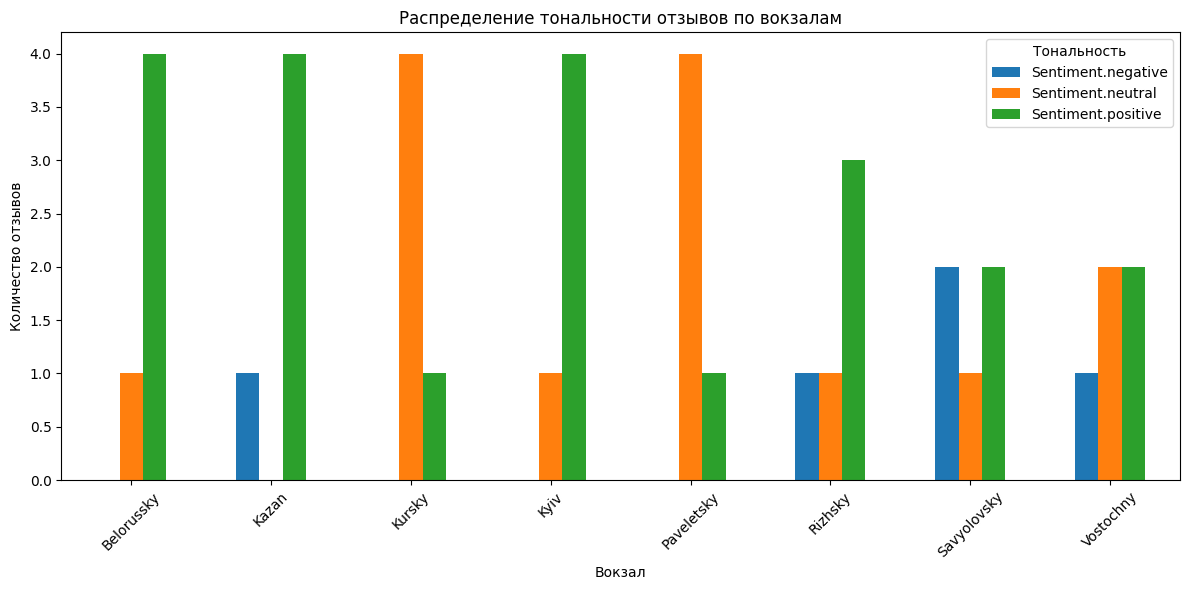

In [ ]:
import matplotlib.pyplot as plt

# Подсчёт тональности по вокзалам
sentiment_counts = df_analyzed.groupby(['station', 'sentiment']).size().unstack(fill_value=0)
sentiment_counts.plot.bar(figsize=(12, 6), title='Распределение тональности отзывов по вокзалам')
plt.xlabel('Вокзал')
plt.ylabel('Количество отзывов')
plt.legend(title='Тональность')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2. Средние оценки по критериям

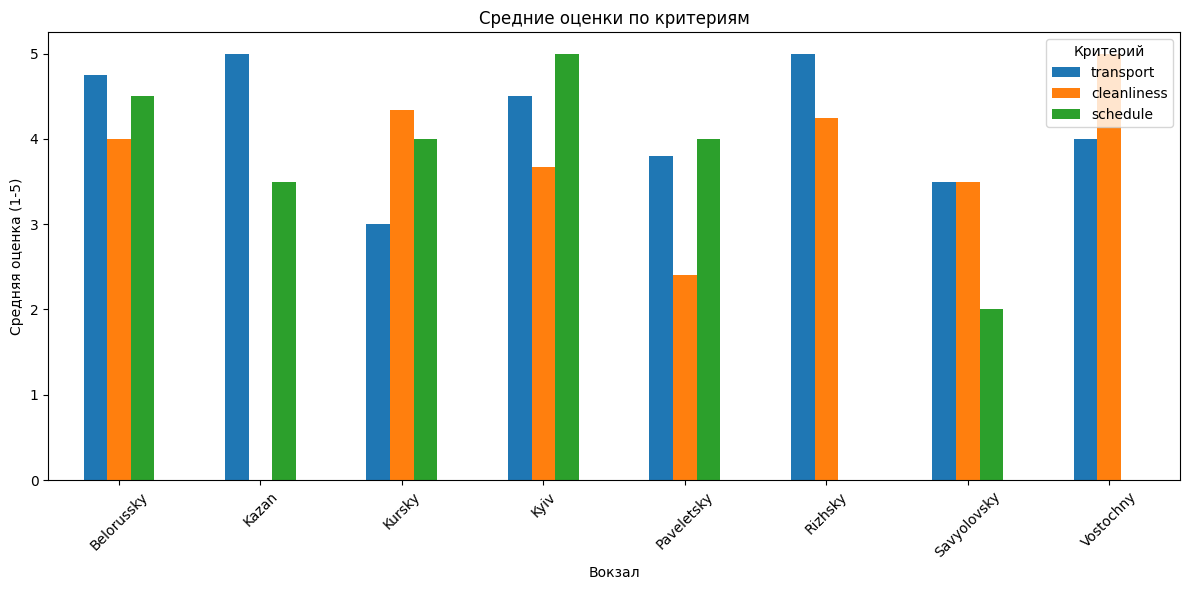

In [ ]:
import numpy as np

# Заменяем 0 на NaN для корректного расчёта средних
for col in ['transport', 'cleanliness', 'schedule']:
    df_analyzed[col] = df_analyzed[col].apply(lambda x: np.nan if x == 0 else x)

# Средние оценки по вокзалам
avg_scores = df_analyzed.groupby('station').agg({
    'transport': 'mean',
    'cleanliness': 'mean',
    'schedule': 'mean'
})

avg_scores.plot.bar(figsize=(12, 6), title='Средние оценки по критериям')
plt.xlabel('Вокзал')
plt.ylabel('Средняя оценка (1-5)')
plt.legend(title='Критерий')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Агрегация положительных и отрицательных моментов

Теперь используем LLM для создания сводки положительных и отрицательных моментов по каждому вокзалу.

In [ ]:
# Собираем все положительные и отрицательные моменты по вокзалам
station_feedback = df_analyzed.groupby('station').agg({
    'positive_points': lambda x: ', '.join(sum(x,[])),
    'negative_points': lambda x: ', '.join(sum(x,[]))
}).reset_index()

station_feedback

,station,positive_points,negative_points
0,Belorussky,"Красивое здание, Близко к метро Белорусская, Х...","Здание выглядит обветшалым, Неудобно для пасса..."
1,Kazan,Удобная и быстрая пересадка с Казанского вокза...,"Только одно табло в главном зале, видимое с од..."
2,Kursky,"ведётся уборка, есть выделенные подъезды для т...","много бродяг и бездомных у вокзала, курение вб..."
3,Kyiv,"Красивый вокзал, Есть всё необходимое для ожид...","Парковка маловата, Туалет нормальный, но не са..."
4,Paveletsky,"Достаточно чисто, Хорошие туалеты, Разнообразн...","Бестолковые досмотры, Проблемы с санузлом, Неу..."
5,Rizhsky,Новые модели поездов выглядят чисто и ухоженно...,"Поезда в ужасном состоянии, особенно старые мо..."
6,Savyolovsky,"В целом вокзал хороший, Удобное расположение р...","Платформа 9 неудобно расположена, Сложный путь..."
7,Vostochny,"Чисто и аккуратно, Круглосуточное кафе, Много ...","Сложная навигация по вокзалу, Путающая планиро..."


In [ ]:
def summarize_feedback(station_name: str, positive_feedback: str, negative_feedback: str) -> str:
    """
    Создаёт краткую сводку положительных и отрицательных моментов для вокзала.
    """
    prompt = f"""Проанализируй отзывы о вокзале {station_name}.

Положительные моменты из отзывов:
{positive_feedback}

Отрицательные моменты из отзывов:
{negative_feedback}

Создай краткую сводку (3-5 предложений) о впечатлениях посетителей от вокзала.
Выдели главные достоинства и недостатки.
"""

    response = client.responses.create(
        model=model,
        instructions="Ты - аналитик. Создавай краткие и информативные сводки.",
        input=prompt
    )

    return response.output_text

In [ ]:
# Создаём сводки для каждого вокзала
summaries = []
for idx, row in tqdm(station_feedback.iterrows(), total=len(station_feedback), desc="Создание сводок"):
    summary = summarize_feedback(row['station'], row['positive_points'], row['negative_points'])
    summaries.append({
        'station': row['station'],
        'summary': summary
    })

df_summaries = pd.DataFrame(summaries)

Создание сводок:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:
# Выводим сводки
for idx, row in df_summaries.iterrows():
    printx(f"### {row['station']}")
    printx(row['summary'])
    printx("---")

### Belorussky

Вокзал Белорусский ценят за удобное расположение в центре Москвы, близость к двум станциям метро, хорошую транспортную доступность и широкий выбор поездов. Пассажиры отмечают чистоту, уют после ремонта, современные зоны ожидания, вежливый персонал и высокий уровень безопасности. Однако к минусам относят неудобства для пассажиров с багажом, старые лестницы без пандусов, сквозные и неуютные кафе, а также временные неудобства из-за текущего благоустройства. Некоторые отзывают неблагополучную атмосферу и необходимость раннего прибытия из-за досмотра. В целом, вокзал воспринимается как функциональный и безопасный, но с рядом архитектурных и бытовых недостатков.

---

### Kazan

Посетители высоко оценивают Казанский вокзал за его красивую архитектуру, просторные залы, яркое освещение и живую атмосферу, отмечая удобную пересадку на МЦД-4 и большое количество кафе, магазинов и мест для ожидания. Персонал вокзала чаще всего описывается как вежливый и готовый помочь. Однако гостей раздражает недостаток информационных табло — в главном зале работает только одно, часто с непонятным отображением статуса поездов, а также почти полное отсутствие рабочих розеток для зарядки. Несмотря на высокий уровень комфорта и удобное расположение, информационная инфраструктура требует модернизации.

...

Вокзал Савёловский в целом оставляет положительное впечатление благодаря удобному расположению рядом со станцией метро, хорошей транспортной доступности, чистоте, свежему ремонту и наличию мест для ожидания. Ключевые достоинства — близость к метро, подземный переход, кафе и терминалы дальнего следования. Однако пассажиры отмечают серьёзные недостатки: неудобную и недоступную платформу 9 без лифта и эскалатора, проблемы с расписанием (неточности, сокращение МЦД, отсутствие электричек вечером), переполненные поезда и платформы, а также претензии к поведению охраны и уборке снега зимой.

---

### Vostochny

Вокзал Vostochny производит современное впечатление: он чистый, светлый, компактный и удобно расположен рядом с МЦД и метро, что обеспечивает лёгкий подъезд и пересадку. Пассажиры отмечают наличие круглосуточного кафе, большого количества автоматов и необходимой инфраструктуры. Однако серьёзными недостатками остаются путающая навигация, неудобная планировка, нехватка касс, розеток и посадочных мест, а также проблемы с парковкой — платная зона неудобна, а бесплатную занимают таксисты. В целом, вокзал удобен для быстрой пересадки, но требует улучшения комфорта и логистики внутри.

---

## Заключение

В этом ноутбуке мы рассмотрели основы работы с Responses API:

1. **Базовые запросы** — отправка простых вопросов модели
2. **Системные промпты** — настройка поведения модели
3. **Контекст диалога** — поддержание связи между запросами с помощью `store` и `previous_response_id`
4. **JSON Mode** — альтернативный способ получения структурированных данных
5. **Structured Outputs** — получение структурированных данных с использованием pydantic
6. **Визуализация** — построение графиков на основе извлечённых данных
7. **Агрегация** — создание сводок с помощью LLM
8. **Мультимодальные модели** - использование изображений на входе модели